# População e cálculo de taxas

**Pergunta que este notebook responde:** como transformar contagens brutas em
**taxas comparáveis** entre estados e municípios de tamanhos diferentes?

Comparar o número absoluto de casos entre São Paulo e Acre não diz quase nada —
São Paulo tem mais de 40 vezes mais habitantes. O que se compara é a
**incidência por 100 mil habitantes**.

**Fonte:** estimativas e projeções populacionais do IBGE, distribuídas pelo
DATASUS.
**Tempo estimado:** 4 a 6 minutos.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
ANO = 2024

## Passo 1 — O que a base do IBGE oferece

In [4]:
from pysus import list_files

catalogo = list_files(dataset="ibge")
tipos = sorted({nome.split("\\")[-1][:4] for nome in catalogo["name"]})

print("Tipos de arquivo disponíveis:", tipos)
print()
print("  POPT/POPB — população total e por faixas")
print("  PROJ      — projeções populacionais")
print("  ESCA/ESCB — escolaridade")
print("  ALFB      — alfabetização")
print("  REND      — renda")
print("  IDOS      — população idosa")

Tipos de arquivo disponíveis: ['ALFB', 'ESCA', 'ESCB', 'IDOS', 'POPB', 'POPT', 'PROJ', 'REND']

  POPT/POPB — população total e por faixas
  PROJ      — projeções populacionais
  ESCA/ESCB — escolaridade
  ALFB      — alfabetização
  REND      — renda
  IDOS      — população idosa


## Passo 2 — Baixar a população

In [5]:
from pysus import ibge

populacao = ibge(year=ANO, as_dataframe=True)

print(f"{len(populacao):,} linhas x {len(populacao.columns)} colunas")
print("Colunas:", list(populacao.columns))
populacao.head()

10,484 linhas x 6 colunas
Colunas: ['ANO', 'UFCOD', 'IDADE', 'SEXO', 'POPULACAO', 'MUNIC_RES']


,ANO,UFCOD,IDADE,SEXO,POPULACAO,MUNIC_RES
0,2024,11,A0000,M,11977,None
1,2024,11,A0101,M,12216,None
2,2024,11,A0202,M,12518,None
3,2024,11,A0303,M,12715,None
4,2024,11,A0404,M,13088,None


A tabela vem detalhada por **UF, idade e sexo**. Para usar como denominador de
uma taxa, somamos a população de cada estado.

In [6]:
import pandas as pd

populacao["POPULACAO"] = pd.to_numeric(populacao["POPULACAO"], errors="coerce").fillna(0)

por_uf = (
    populacao.groupby("UFCOD")["POPULACAO"]
    .sum()
    .astype(int)
)

UFS = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}

por_uf.index = [UFS.get(int(c), str(c)) for c in por_uf.index]
por_uf = por_uf[[i for i in por_uf.index if isinstance(i, str) and len(i) == 2]]

print(f"População total do Brasil em {ANO}: {por_uf.sum():,}")
por_uf.sort_values(ascending=False).head(8).to_frame("População")

População total do Brasil em 2024: 212,583,750


,População
SP,45973194
MG,21322691
RJ,17219679
BA,14850513
PR,11824665
RS,11229915
PE,9539029
CE,9233656


## Passo 3 — Juntar com dados de doença e calcular a taxa

Vamos usar a dengue de 2024 como exemplo. Lemos apenas a coluna do estado, que
é tudo o que precisamos para contar casos por UF.

In [7]:
from pysus import sinan

caminhos = sinan(disease="DENG", year=ANO, as_dataframe=False)
casos = pd.read_parquet(caminhos[0], columns=["SG_UF_NOT"])

UFS_TEXTO = {str(k): v for k, v in UFS.items()}
casos_por_uf = casos["SG_UF_NOT"].astype(str).map(UFS_TEXTO).value_counts()

print(f"Total de notificações: {casos_por_uf.sum():,}")
casos_por_uf.head()

Total de notificações: 6,564,924


SG_UF_NOT
SP    2182413
MG    1658372
PR     647663
SC     336334
GO     334182
Name: count, dtype: int64

### A conta

$$\text{incidência} = \frac{\text{casos}}{\text{população}} \times 100.000$$

In [8]:
tabela = pd.DataFrame({
    "Casos": casos_por_uf,
    "População": por_uf,
}).dropna()

tabela["Incidência por 100 mil"] = (
    tabela["Casos"] / tabela["População"] * 100_000
).round(1)

tabela = tabela.sort_values("Incidência por 100 mil", ascending=False)
tabela.head(10)

,Casos,População,Incidência por 100 mil
DF,279020,2982818,9354.2
MG,1658372,21322691,7777.5
PR,647663,11824665,5477.2
SP,2182413,45973194,4747.1
GO,334182,7350483,4546.4
SC,336334,8058441,4173.7
ES,137871,4102129,3361.0
RS,224791,11229915,2001.7
RJ,302190,17219679,1754.9
BA,231942,14850513,1561.8


## Passo 4 — A diferença que isso faz

Compare as duas leituras: quem tem **mais casos** e quem tem **mais casos por
habitante**. São listas diferentes — e a segunda é a que orienta decisões.

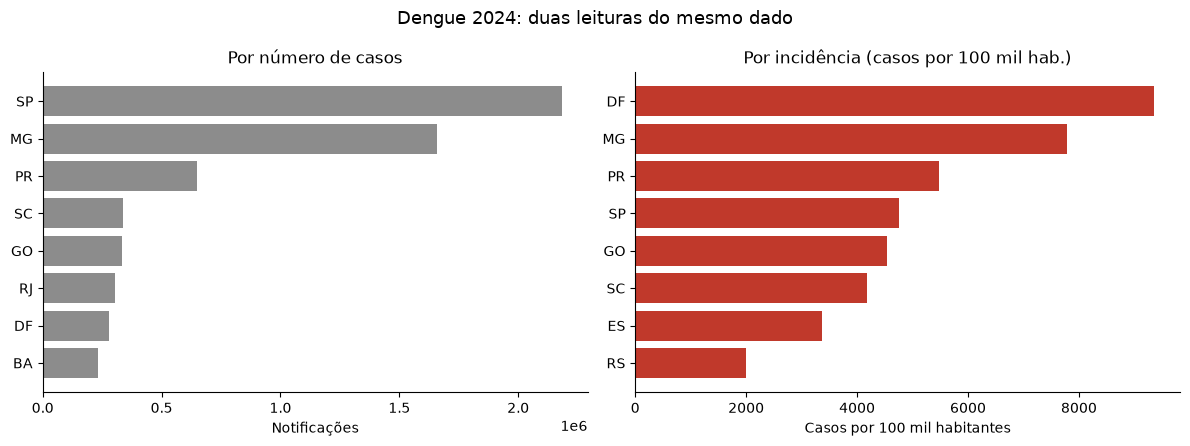

In [9]:
import matplotlib.pyplot as plt

por_casos = tabela.sort_values("Casos", ascending=False).head(8)
por_taxa = tabela.sort_values("Incidência por 100 mil", ascending=False).head(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.barh(por_casos.index[::-1], por_casos["Casos"][::-1], color="#8c8c8c")
ax1.set_title("Por número de casos", fontsize=12)
ax1.set_xlabel("Notificações")

ax2.barh(por_taxa.index[::-1], por_taxa["Incidência por 100 mil"][::-1], color="#c0392b")
ax2.set_title("Por incidência (casos por 100 mil hab.)", fontsize=12)
ax2.set_xlabel("Casos por 100 mil habitantes")

for eixo in (ax1, ax2):
    eixo.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Dengue {ANO}: duas leituras do mesmo dado", fontsize=13)
plt.tight_layout()
plt.show()

## Como adaptar

- **Qualquer indicador:** a mesma receita serve para mortalidade, internações,
  cobertura vacinal — basta trocar o numerador.
- **Por município:** o IBGE também distribui população municipal; use o código
  IBGE de 6 dígitos como chave.
- **Por faixa etária:** a tabela do IBGE já vem por idade e sexo, permitindo
  taxas específicas (por exemplo, mortalidade infantil ou incidência em idosos).

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*